# Evaluate **Paraphrasing**

Our imposter approach needs models to reword an original text keeping the same meaning.
Ideally, we want to model the way texts originated.
This is dependent on the text's genre, i.e. a student essay originates from a task description and a list of URLs while a new article originates from a list of additional sources or from spectating an event.
We implemented both a naive approach to rewording a text and a more sophisticated one:
- given a prompt and a text, the naive approach uses a language model to paraphrase the text
- given a prompt and a text LLM A is used to extract the text's genre, tone and summary of bullet points, then LLM B is used to reword the text in the same genre and tone based on the summary of bullet points

In [ ]:
from pathlib import Path
import os
import textwrap
import sys
import pandas as pd

# Add the root of the project to Python path
sys.path.append(os.path.abspath(".."))
from genai_detection.config import CONFIG
from genai_detection.paraphrasing.paraphraser import (
    T5ChatGPTParaphraser,
    T5GooglePAWSParaphraser,
    BulletPointParaphraser,
    OllamaParaphraser,
    TaskParaphraser,
    TopicParaphraser,
    TitleParaphraser,
    TranslationParaphraser,
)
from genai_detection.experiments.paraphrases.paraphraser_evaluation import ParaphrasingEvaluator

/Users/klara/Library/Caches/pypoetry/virtualenvs/generative-ai-detection-PkLo9Jli-py3.11/lib/python3.11/site-packages/pyemd/__init__.py:74: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from .emd import emd, emd_with_flow, emd_samples
[nltk_data] Downloading package wordnet to /Users/klara/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


## Original text
We use a CNN news article from 23.06.2025/ 04.07.2025 as an example.

In [2]:
USE_GROUND_TRUTH = True  # If True, use ground truth metadata from the dataset (if present), otherwise use LLM extracted metadata
path2results = Path(os.getcwd()).resolve().parent / CONFIG.SAVE_PATH / "paraphrasing"
category2directory = {  # value: directory name and one file name in the datasets folder
    "News": [
        "custom_texts",
        "cnn_040725",
    ],  # Dalai Lama; "cnn_230625"    # USA attacks Iran
    "Blog": ["blog_corpus", 27],
    "Gutenberg": ["gutenberg", "Othello_the_Moor_of_Venice_William_Shakespeare"],
    "Student Essay": [
        "student_essays/Intro2006",
        "Ass1/2006_AB4847",
    ],  # stream of consciousness essay: 18 years old girl who writes about her bipolar ex-boyfriend of 8 months and her new boyfriend who loves music like her but is not catholic; she wants to live in the present
}

# This is used for plot titles in the notebook
# data_category = "Blog"
data_category = "News"
# data_category = "Gutenberg"
# data_category = "Student Essay"
path2datasets = (
    Path(os.getcwd()).resolve().parent
    / "data"
    / "datasets"
    / category2directory[data_category][0]
)
if data_category not in ["News", "Gutenberg"] and USE_GROUND_TRUTH:
    # Student Essay dataset has metadata, but none of the information we extract, hence we set USE_GROUND_TRUTH to False
    print(
        f"Data category {data_category} has no metadata file, USE_GROUND_TRUTH was set to False."
    )
    USE_GROUND_TRUTH = False
path2metadata = path2datasets / "file_metadata.xlsx"
assert path2datasets.exists(), f"Path to datasets {path2datasets} does not exist."
assert path2results.exists(), f"Path to results {path2results} does not exist."

file_name = category2directory[data_category][1]
original_text = (
    open(path2datasets / f"{file_name}.txt").read()
    if data_category != "Blog"
    else pd.read_csv(path2datasets / f"blogtext.csv").loc[file_name, "text"]
)
metadata = (
    pd.read_excel(path2metadata, index_col="filename").loc[file_name].dropna().to_dict()
    if USE_GROUND_TRUTH
    else {}
)
print(f"Metadata for {file_name}: {metadata}")

print(textwrap.fill(original_text, width=80))

Metadata for cnn_040725: {'time_period': 2025, 'topic': 'Dalai Lama, Birthday, China', 'genre': 'News', 'century': 21}
  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an increasingly powerful Beijing has
become ever more assertive in suppressing it.  As his 90th birthday approaches
this Sunday, the spiritual leader for millions of followers of Tibetan Buddhism
worldwide is bracing for a final showdown with Beijing: the battle over who will
control his reincarnation.  On Wednesday, the Dalai Lama announced that he will
have a successor after his death, and that his office will have the sole
authority to identify his reincarnation.  “I am affirming that the institution
of the Dalai Lama will continue,” the Nobel Peace laureate said in a video
message to religious elders gathering in Dharamshala, India, where he has found
refuge since Chinese c

## Naive Approach

In [ ]:
ollama_version = "zephyr:7b"  # "mistral:7b"  # "default:latest"
paraphrasers = {
    "T5_ChatGPT": T5ChatGPTParaphraser(),
    "T5_Google_PAWS": T5GooglePAWSParaphraser(),
    "Ollama": OllamaParaphraser(model_id=ollama_version),
}

You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [4]:
n_responses = 1  # number of paraphrases to generate
max_length = 512  # Maximum length of the generated paraphrase
temperature = 0.7  # Controls the randomness of the output. Lower values make the output more deterministic.

prompts = [
    "Paraphrase the text above and output only the paraphrased version.",
    "For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).",
    "For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.",
    "For the text above: Paraphrase the sentence using the same tone as the original with approximately the same number of words.",
    "For the text above: Paraphrase this sentence. Do not change the meaning, but use different words and structure. Output only the paraphrased sentence.",
]

## Bullet Point Approach

Ollama models are by far the best ones for extracting the genre, tone and summary of bullet points and returning them in a structured way.
Hence, we use the Ollama model as the text extractor and any other model as the text generator.

In [5]:
models = {
    "text_extractor": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
    "text_generator": {
        "name": "Ollama-latest",
        "model": OllamaParaphraser(model_id=ollama_version),
    },
}
bullet_point_paraphraser = BulletPointParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Task Paraphraser
The task paraphraser extracts the task, tone and genre from the text and then generates a paraphrase based on this information.

In [6]:
task_paraphraser = TaskParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Topic Paraphraser
The topic paraphraser extracts the topic, tone and genre from the text and then generates a paraphrase based on this information.

In [7]:
topic_paraphraser = TopicParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Title Paraphraser
The title paraphraser extracts the title, tone and genre from the text and then generates a paraphrase based on this information.

In [8]:
title_paraphraser = TitleParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

# Translation Paraphraser
The translation paraphraser first translates the text to a different language and then translates it back to the original language/ English.
The user can specify the language to translate to.

In [9]:
translation_paraphraser = TranslationParaphraser(
    text_extractor=models["text_extractor"]["model"],
    text_generator=models["text_generator"]["model"],
)

## Evaluating the Approaches

In [10]:
paraphrasers.update(
    {
        "BulletPoint": bullet_point_paraphraser,
        "Task": task_paraphraser,
        "Topic": topic_paraphraser,
        "Title": title_paraphraser,
        "Translation": translation_paraphraser,
    }
)

paraphrase_evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=prompts,
    original_text=original_text,
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
    ground_truth=metadata,  # if USE_GROUND_TRUTH else None
)
df, extremest_paraphrases = paraphrase_evaluator.evaluate(
    save_extremest_paraphr_per_score=True, save_to_disk=True
)
display(df)

[DEBUG] Total configurations to evaluate: 40, [(('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x35fbacdd0>), 'Paraphrase the text above and output only the paraphrased version.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x35fbacdd0>), 'For the text above: First, extract bullet points capturing the main ideas, then create a text based on these bullet points. Only output the final text (i.e. do not output the bullet points or any additional chain of thoughts).', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x35fbacdd0>), 'For the text above: Paraphrase the sentence by first identifying the main subject, verb, and object. Then find synonyms for each and construct a new sentence. Only output the final paraphrased sentence.', 0.7), (('T5_ChatGPT', <genai_detection.paraphrasing.paraphraser.T5ChatGPTParaphraser object at 0x35fbacdd0>), 'For the text

Evaluating Paraphrasers:  52%|█████▎    | 21/40 [04:36<08:30, 26.85s/it]

Again, result:  {"task":"Summarize the article 'For Much of the Past Century, the Dalai Lama Has Been the Living Embodiment of Tibet's Struggle for Greater Freedoms Under Chinese Communist Party Rule' and provide instructions for an LLM to reproduce it.", "tone":"Informative", "time_period":1950-present, "language_register":"Formal", "target_audience":"Academics and journalists specializing in Tibetan studies", "genre":"News article"}


Evaluating Paraphrasers:  60%|██████    | 24/40 [06:13<07:56, 29.77s/it]

Again, result:  {Task: Write a news article about the Dalai Lama's announcement regarding his successor and the controversy surrounding it. The piece should explore the cultural and political significance of reincarnation in Tibetan Buddhism, the role of the Dalai Lama as both a spiritual leader and a symbol of Tibetan identity, and the geopolitical implications of Beijing's claim to approve all reincarnations of high-ranking lamas. The article should also address the potential impact of the Dalai Lama's death on the Tibetan exile community and the future of the middle way approach. Use an objective tone, and provide quotes from experts and religious elders gathered in Dharamshala for context. Format: JSON object with "task": "Write a news article about the Dalai Lama's announcement regarding his successor and the controversy surrounding it", "tone": "objective", "time_period": "present", "language_register": "formal", "target_audience": "general readers interested in international pol

...

Evaluating Paraphrasers:  98%|█████████▊| 39/40 [11:37<00:07,  7.05s/it]

[DEBUG] Using TranslationParaphraser with prompt: Translate the text above into French. Do not use direct quotes or newlines. Output only the translated text, without any additional commentary or formatting.
[DEBUG] Using TranslationParaphraser with prompt: Translate the text above into French. Do not use direct quotes or newlines. Output only the translated text, without any additional commentary or formatting.


Evaluating Paraphrasers: 100%|██████████| 40/40 [11:37<00:00, 17.44s/it]


Results saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_results_comparison_temp0.7_maxLength512.csv


,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,rougeLsum,bertscore_precision,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta
0,T5_ChatGPT,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Tibetan Buddhists are bracing themselves for a...,8.033198e-12,0.018051,0.055285,0.016313,0.045528,0.045528,0.818014,0.676909,0.740802,0.081909,0.790327,distilbert-base-uncased_L5_no-idf_version=0.3....,0.621592,0.033604,0.587988
1,T5_ChatGPT,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Tibetan Buddhists are bracing themselves for a...,8.033198e-12,0.018051,0.055285,0.016313,0.045528,0.045528,0.818014,0.676909,0.740802,0.081909,0.790327,distilbert-base-uncased_L5_no-idf_version=0.3....,0.621592,0.033604,0.587988
2,T5_ChatGPT,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Tibetan Buddhists are bracing themselves for a...,8.033198e-12,0.018051,0.055285,0.016313,0.045528,0.045528,0.818014,0.676909,0.740802,0.081909,0.790327,distilbert-base-uncased_L5_no-idf_version=0.3....,0.621592,0.033604,0.587988
3,T5_ChatGPT,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Tibetan Buddhists are bracing themselves for a...,8.033198e-12,0.018051,0.055285,0.016313,0.045528,0.045528,0.818014,0.676909,0.740802,0.081909,0.790327,distilbert-base-uncased_L5_no-idf_version=0.3....,0.621592,0.033604,0.587988
4,T5_ChatGPT,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Tibetan Buddhists are bracing themselves for a...,8.033198e-12,0.018051,0.055285,0.016313,0.045528,0.045528,0.818014,0.676909,0.740802,0.081909,0.790327,distilbert-base-uncased_L5_no-idf_version=0.3....,0.621592,0.033604,0.587988
5,T5_Google_PAWS,Paraphrase the text above and output only the ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",The Dalai Lama has been the living embodiment ...,6.336112e-04,0.080095,0.199396,0.148485,0.157100,0.157100,0.857634,0.735911,0.792123,0.148522,0.915587,distilbert-base-uncased_L5_no-idf_version=0.3....,0.689955,0.119043,0.570912
6,T5_Google_PAWS,"For the text above: First, extract bullet poin...","{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",The Dalai Lama has been the living embodiment ...,1.353689e-03,0.096059,0.228487,0.178571,0.175074,0.175074,0.864768,0.745903,0.800949,0.162957,0.858565,distilbert-base-uncased_L5_no-idf_version=0.3....,0.686628,0.134972,0.551657
7,T5_Google_PAWS,For the text above: Paraphrase the sentence by...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",The Dalai Lama was the living embodiment of th...,1.039403e-04,0.071381,0.171254,0.104294,0.134557,0.134557,0.830937,0.728781,0.776514,0.156984,0.857471,distilbert-base-uncased_L5_no-idf_version=0.3....,0.670137,0.101971,0.568166
8,T5_Google_PAWS,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",The Dalai Lama is sometimes praised for his ef...,4.537075e-04,0.083308,0.196672,0.139605,0.166415,0.166415,0.865035,0.744059,0.799999,0.124197,0.898692,distilbert-base-uncased_L5_no-idf_version=0.3....,0.686396,0.121180,0.565216
9,T5_Google_PAWS,For the text above: Paraphrase this sentence. ...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",The

In [11]:
df["paraphrased_text"].values

array(['Tibetan Buddhists are bracing themselves for a potential confrontation with Beijing, who has been resisting the idea of deposing Dalai Lama for over three decades.',
       'Tibetan Buddhists are bracing themselves for a potential confrontation with Beijing, who has been resisting the idea of deposing Dalai Lama for over three decades.',
       'Tibetan Buddhists are bracing themselves for a potential confrontation with Beijing, who has been resisting the idea of deposing Dalai Lama for over three decades.',
       'Tibetan Buddhists are bracing themselves for a potential confrontation with Beijing, who has been resisting the idea of deposing Dalai Lama for over three decades.',
       'Tibetan Buddhists are bracing themselves for a potential confrontation with Beijing, who has been resisting the idea of deposing Dalai Lama for over three decades.',
       "The Dalai Lama has been the living embodiment of Tibet's struggle for greater freedoms under Chinese Communist Party rule 

### Extremest (i.e. best and worst) paraphrases per metric

In [12]:
display(extremest_paraphrases)

,model,prompt,parameters,original_text,paraphrased_text,bleu_score,meteor_score,rouge1,rouge2,rougeL,...,bertscore_recall,bertscore_f1,sbert_wms,sbert_cos,bertscore_hash,sem_sim_avg,syn_sim_avg,gohsen_delta,metric,extreme
0,Translation,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.517726,distilbert-base-uncased_L5_no-idf_version=0.3....,0.103545,0.000000,0.103545,bleu_score,min
1,BulletPoint,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",As the 90th birthday of His Holiness the Dalai...,1.922488e-01,0.357115,0.575152,0.241950,0.225891,...,0.802740,0.813271,0.295138,0.933132,distilbert-base-uncased_L5_no-idf_version=0.3....,0.733672,0.331097,0.402575,bleu_score,max
2,Translation,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.517726,distilbert-base-uncased_L5_no-idf_version=0.3....,0.103545,0.000000,0.103545,meteor_score,min
3,BulletPoint,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",As the 90th birthday of His Holiness the Dalai...,1.922488e-01,0.357115,0.575152,0.241950,0.225891,...,0.802740,0.813271,0.295138,0.933132,distilbert-base-uncased_L5_no-idf_version=0.3....,0.733672,0.331097,0.402575,meteor_score,max
4,Translation,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.517726,distilbert-base-uncased_L5_no-idf_version=0.3....,0.103545,0.000000,0.103545,rouge1,min
5,BulletPoint,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",As the 90th birthday of His Holiness the Dalai...,1.922488e-01,0.357115,0.575152,0.241950,0.225891,...,0.802740,0.813271,0.295138,0.933132,distilbert-base-uncased_L5_no-idf_version=0.3....,0.733672,0.331097,0.402575,rouge1,max
6,Translation,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.517726,distilbert-base-uncased_L5_no-idf_version=0.3....,0.103545,0.000000,0.103545,rouge2,min
7,Ollama,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Reiterating his commitment to the continuation...,9.414536e-02,0.275917,0.466413,0.383736,0.403042,...,0.808374,0.844986,0.282112,0.913116,distilbert-base-uncased_L5_no-idf_version=0.3....,0.746732,0.321200,0.425532,rouge2,max
8,Translation,None <TEXT>,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",,0.000000e+00,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.517726,distilbert-base-uncased_L5_no-idf_version=0.3....,0.103545,0.000000,0.103545,rougeL,min
9,Ollama,For the text above: Paraphrase the sentence us...,"{'n_responses': 1, 'max_tokens': 512, 'tempera...","For much of the past century, the Dalai Lama h...",Reiterating his commitment to the continuation...,9.414536e-02,0.275917,0.466413,0.383736,0.403042,...,0.808374,0.844986,0.282112,0.913116,distilbert-base-uncased_L5_no-idf_version=0.3....,0.746732,0.321200,0.425532,rougeL,max


In [13]:
print("### Extremest (i.e. best and worst) paraphrases per metric")
print("Original text:")
print(textwrap.fill(original_text[:200], width=80), "...")

for index, row in extremest_paraphrases.iterrows():
    print(f"Metric: {row['extreme']} {row['metric']}")
    print(
        f"Paraphrase by {row['model']}: {textwrap.fill(row['paraphrased_text'], width=80)}"
    )
    # print(f"Prompt: {row['prompt']}")
    print("-" * 80)

### Extremest (i.e. best and worst) paraphrases per metric
Original text:
  For much of the past century, the Dalai Lama has been the living embodiment of
Tibet’s struggle for greater freedoms under Chinese Communist Party rule,
sustaining the cause from exile even as an in ...
Metric: min bleu_score
Paraphrase by Translation: 
--------------------------------------------------------------------------------
Metric: max bleu_score
Paraphrase by BulletPoint: As the 90th birthday of His Holiness the Dalai Lama approaches, the spiritual
leader of millions of Tibetan Buddhists worldwide is preparing for a final
showdown with Beijing: the battle over who will control his reincarnation. The
reincarnation of the current Dalai Lama is not just significant to Tibetan
Buddhism but has geopolitical implications for the broader Himalayan region, as
it could potentially lead to Tibetans and Tibetan Buddhists globally rejecting
any candidate selected by Beijing. China's ruling Communist Party claims


Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_model_radar_chart_20250727_141811.png


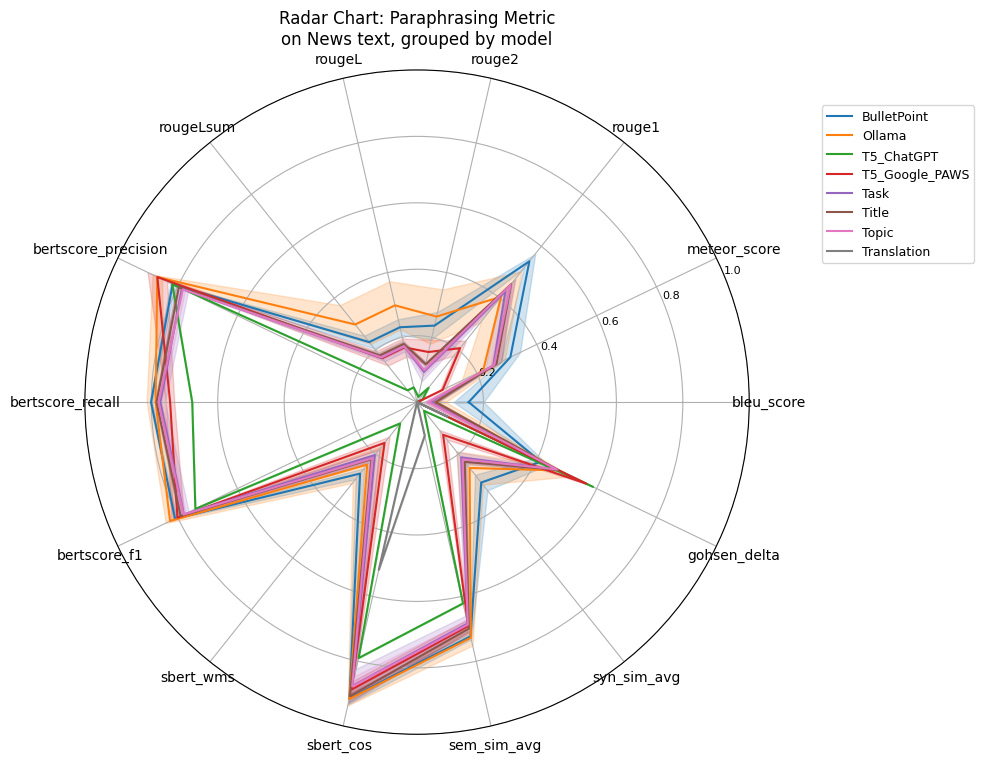

In [14]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/paraphrasing_metrics_grouped_by_prompt_radar_chart_20250727_141811.png


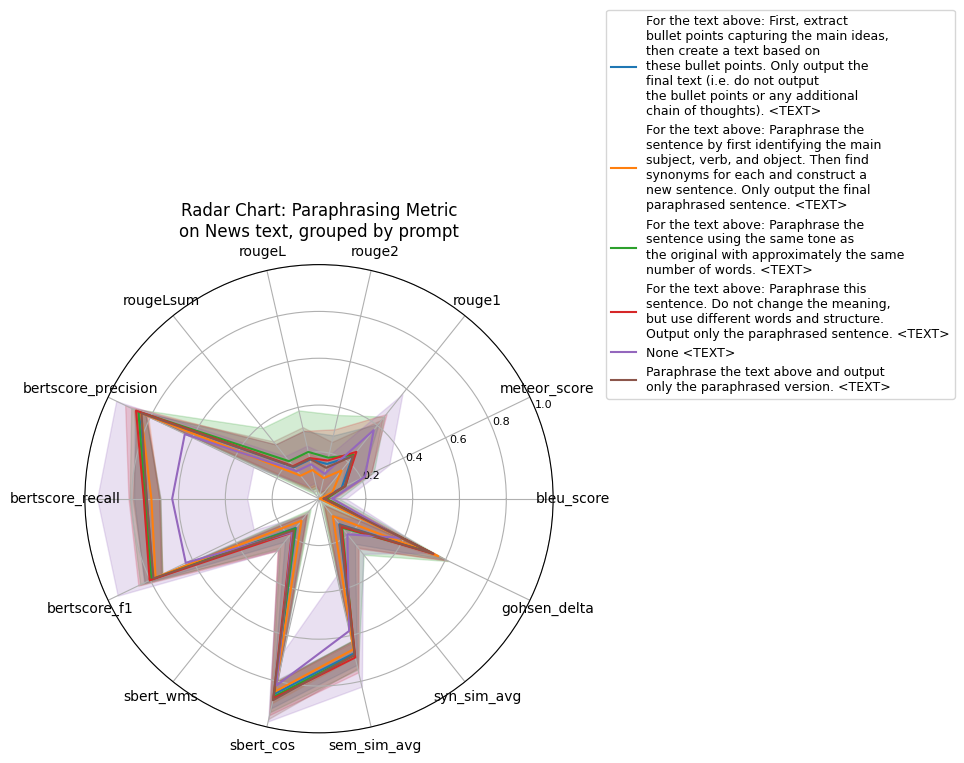

In [15]:
paraphrase_evaluator.plot_models_metrics(
    df=df, save_path=path2results, data_category=data_category, group_by="prompt"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_Paraphraser_20250727_141812.png


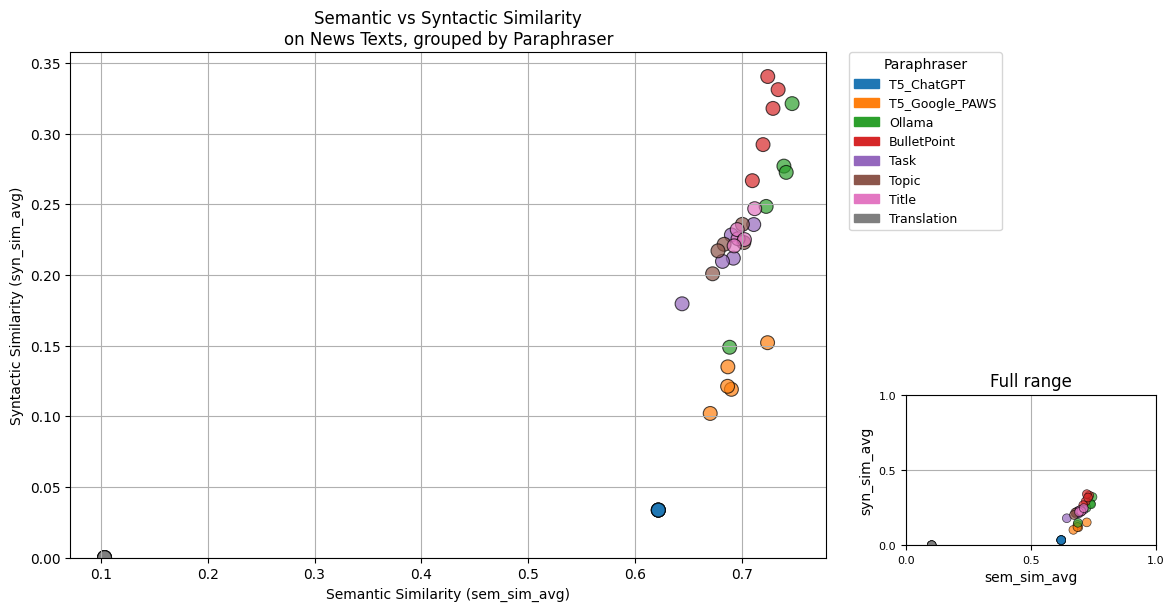

In [16]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/sem_syn_scatter_grouped_by_prompt_20250727_141812.png


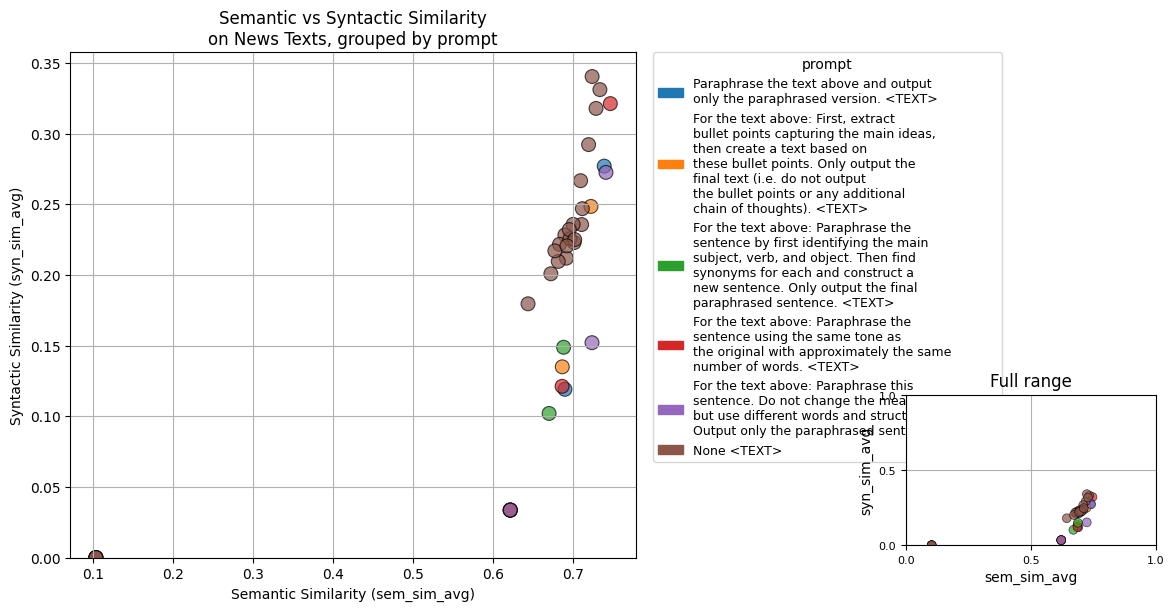

In [17]:
paraphrase_evaluator.plot_metric_scatter(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

### Kernel Density Estimation (KDE)
- KDE estimates probability density PDF
- The y-axis is density/ concentration/ likelihood, not probability.
- Density can be greater than 1 if data are tightly clustered in a small range.
- For example, if many data points lie very close together, the curve can be sharp and tall (high density), so y-values exceed 1.
- The important property is that the **integral (area) under the curve is 1**, not that the max height is ≤1.

/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1105: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1105: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1105: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:1105: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable t

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_Paraphraser_20250727_141813.png


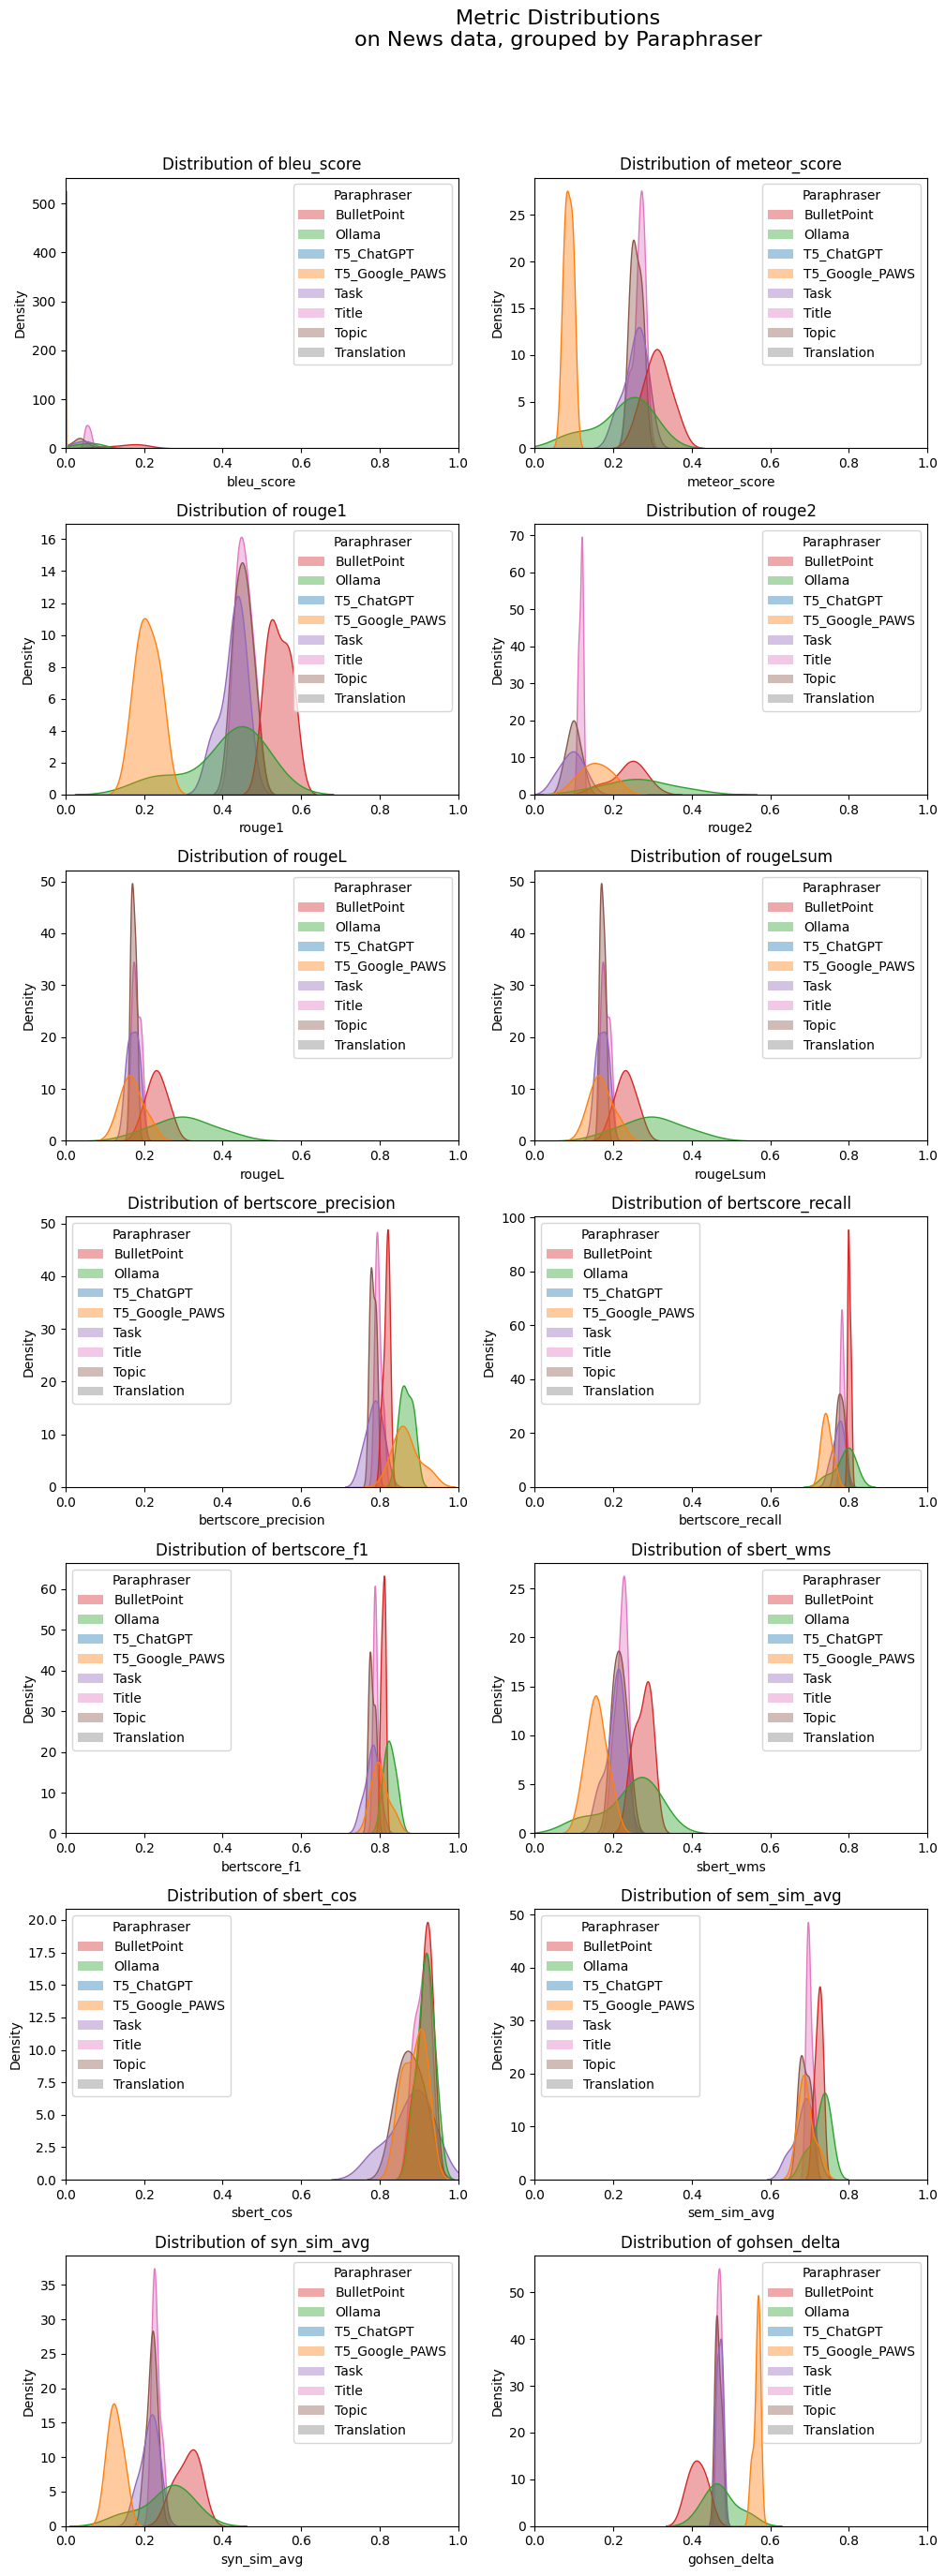

In [18]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="model"
)

Plot saved to /Users/klara/Developer/Uni/MA/artificial-authorship-verification/results/paraphrasing/metric_distributions_grouped_by_prompt_20250727_141815.png


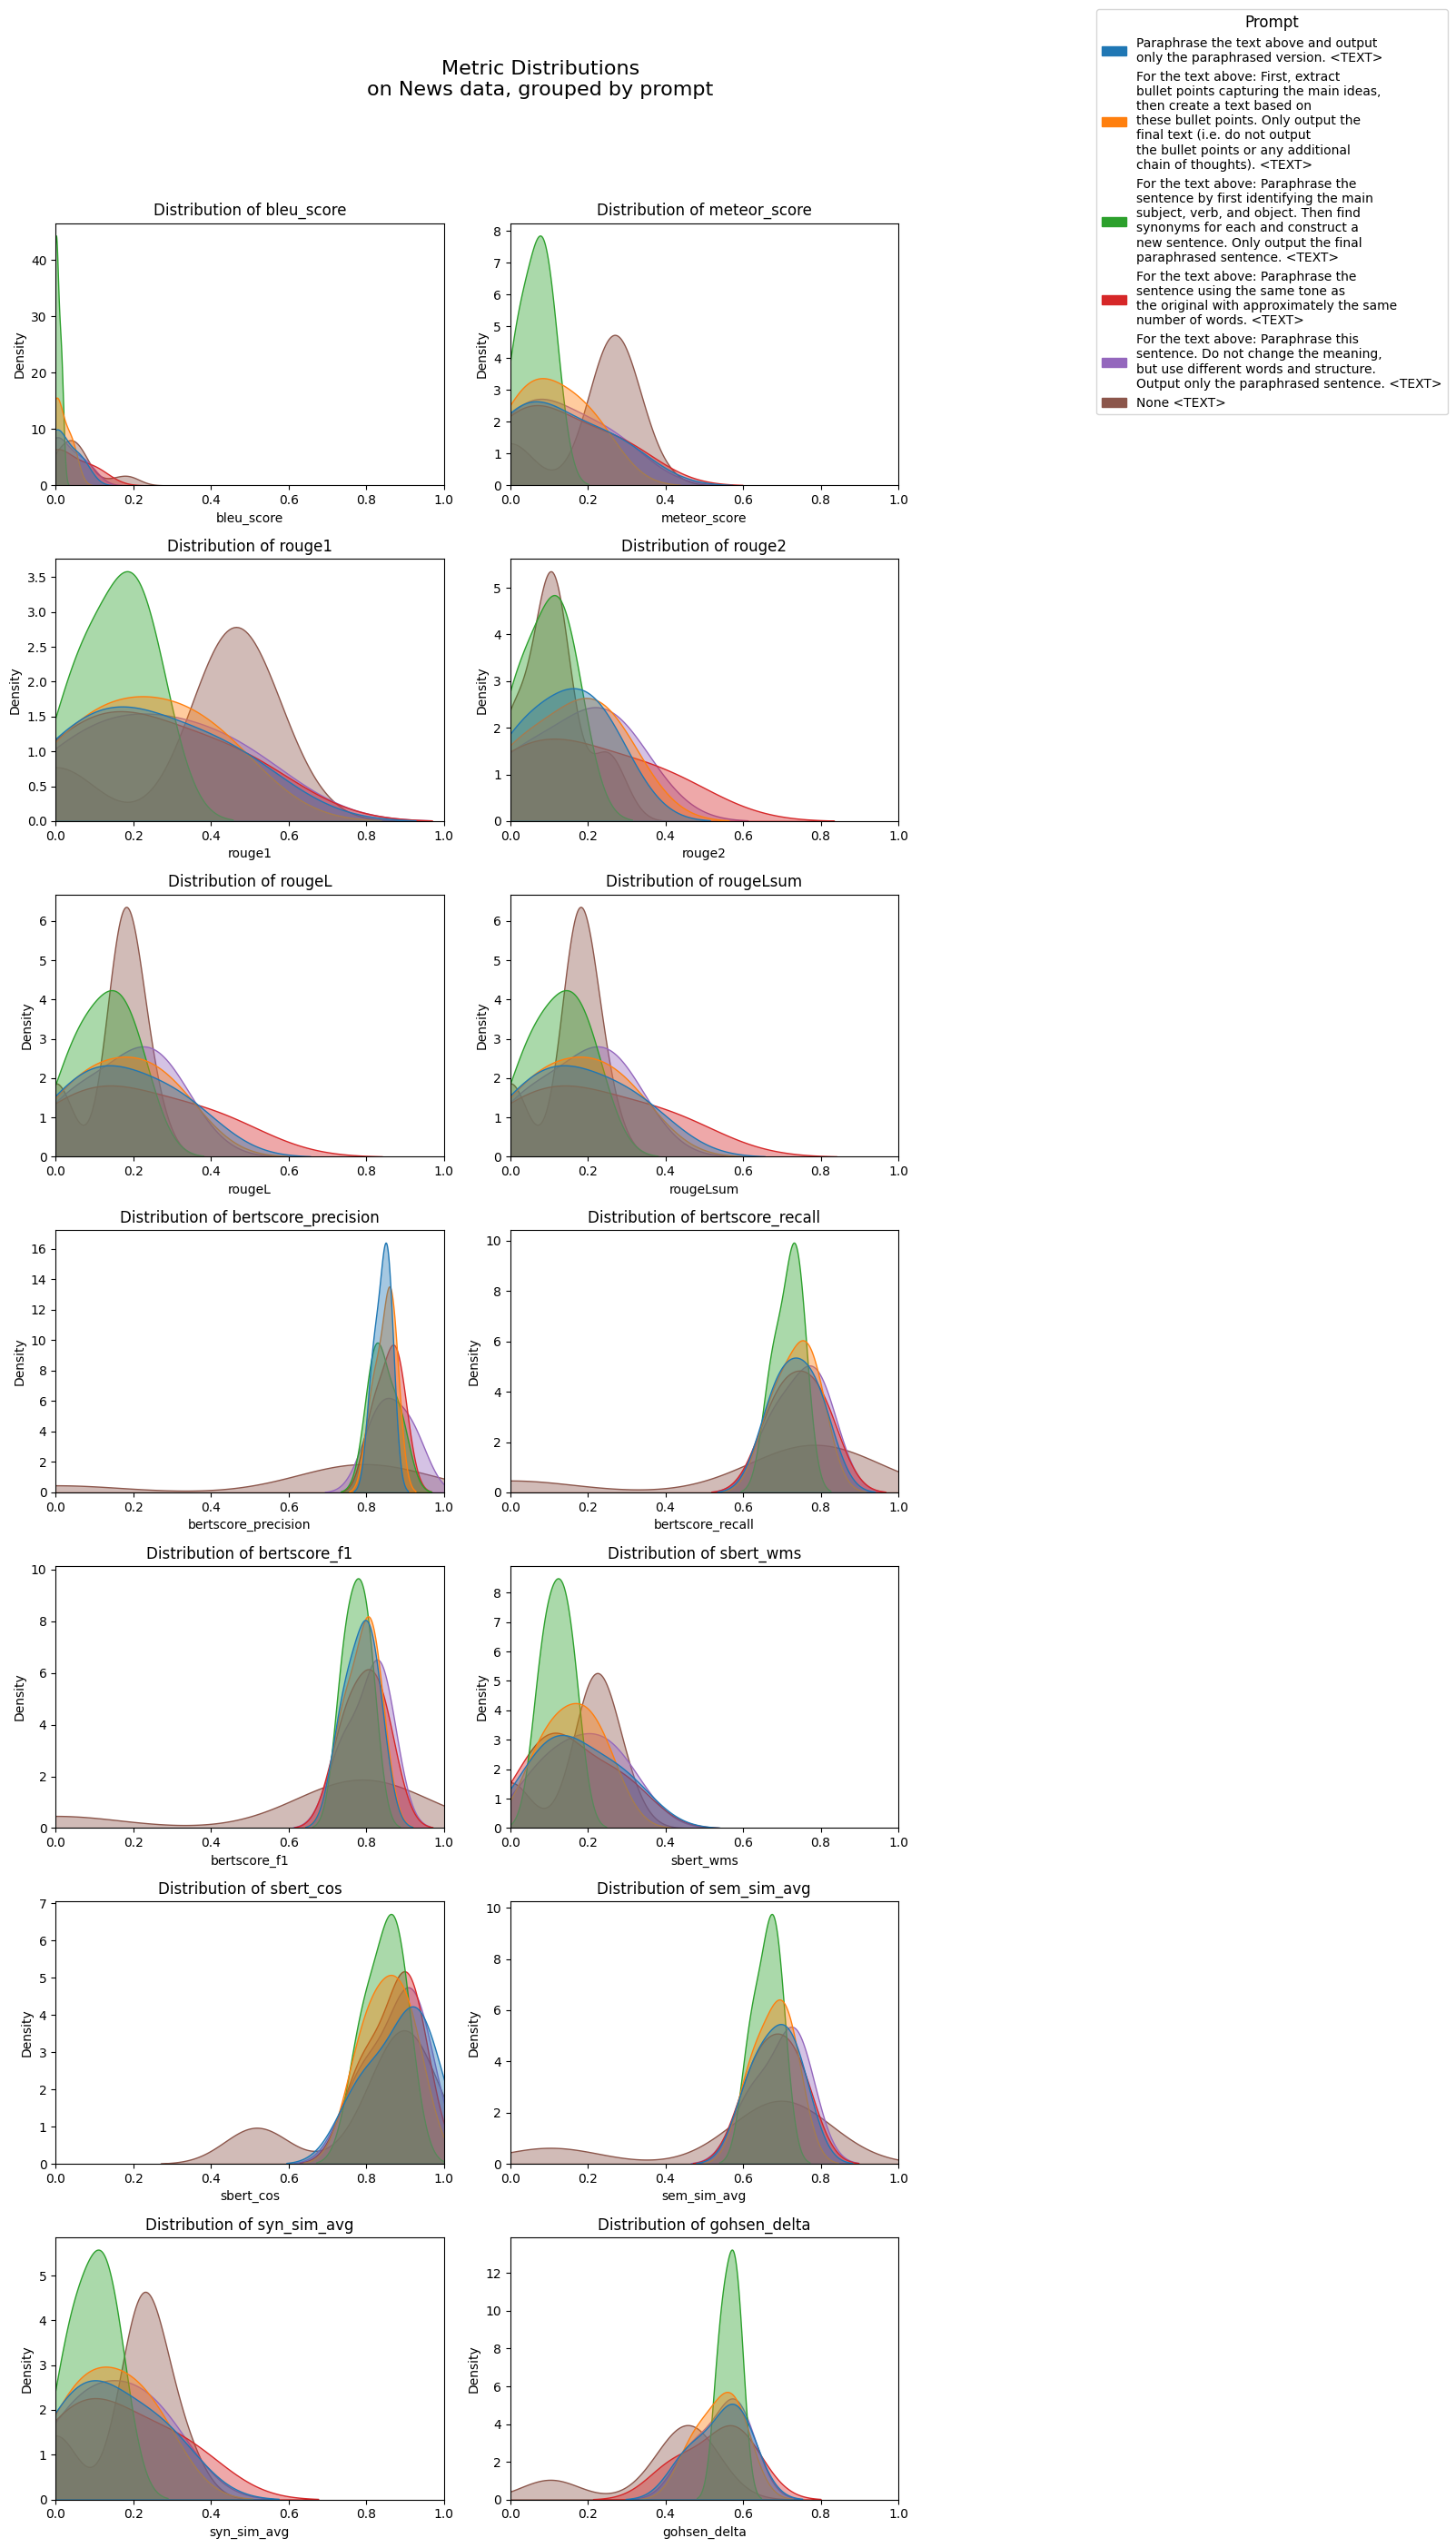

In [19]:
paraphrase_evaluator.plot_metric_distributions(
    df, save_path=path2results, data_category=data_category, group_by="prompt"
)

# Evaluation for text extractor of Non-Naive Paraphrasers

In [20]:
n_responses = 3  # number of paraphrases to generate
paraphrasers = {
    # "Ollama": OllamaParaphraser(model_id=ollama_version),
    "TopicParaphraser": TopicParaphraser(
        text_extractor=OllamaParaphraser(model_id=ollama_version),
        text_generator=OllamaParaphraser(model_id=ollama_version),
    ),
    # "TaskParaphraser": TaskParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "TitleParaphraser": TitleParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
    # "BulletPointParaphraser": BulletPointParaphraser(
    #     text_extractor=OllamaParaphraser(model_id=ollama_version),
    #     text_generator=OllamaParaphraser(model_id=ollama_version),
    # ),
}
evaluator = ParaphrasingEvaluator(
    paraphrasers=paraphrasers,
    prompts=[
        "Paraphrase the following text and output only the paraphrased version:"
    ],  # use a single prompt for simplicity
    original_text="not used",  # self.base_dir contains fixed texts to test on
    n_responses=n_responses,
    max_length=max_length,
    temperature=temperature,
    config={"save_path": path2results},
)

Dataset snapshot:
    filename gender  age              topic      sign          date  \
2    2059027   male   15            Student       Leo   12,May,2004   
5    3581210   male   33  InvestmentBanking  Aquarius  10,June,2004   
12   3581210   male   33  InvestmentBanking  Aquarius  09,June,2004   
19   3581210   male   33  InvestmentBanking  Aquarius  16,June,2004   
27   3581210   male   33  InvestmentBanking  Aquarius  01,July,2004   

                                                 text  year  century  
2   In het kader van kernfusie op aarde: MAAK JE E...  2004       21  
5   I had an interesting conversation with my Dad ...  2004       21  
12  Last night was pretty fun...mostly because of ...  2004       21  
19  So I've been in Vancouver a few days now...in ...  2004       21  
27  This may be a long blog...got a lot of thought...  2004       21  


Evaluating TopicParaphraser: 100%|██████████| 10/10 [21:58<00:00, 131.86s/it]


[DEBUG] Results DataFrame for TopicParaphraser of len 10:
   filename  genre_match  time_match  topic_match  original_length  \
0   2059027        False       False     0.000000             4322   
1   3581210        False       False     0.130000              660   
2   3581210        False       False     0.031546              512   
3   3581210        False       False     0.013841              806   
4   3581210        False       False     0.025974              933   

   paraphrase_length ground_truth_genre  ground_truth_century  \
0                826                                       21   
1                633                                       21   
2                576                                       21   
3                663                                       21   
4                679                                       21   

  ground_truth_topic                                    extracted_topic  \
0            Student  {'topic': 'home ownership of nucl

Evaluating TopicParaphraser:  10%|█         | 1/10 [08:50<1:19:34, 530.54s/it]WARNING:genai_detection.paraphrasing.paraphraser_evaluation:Extraction failed for file 'MOBY-DICK_Herman_Melville': <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>
Evaluating TopicParaphraser:  40%|████      | 4/10 [16:30<23:21, 233.63s/it]  

[ERROR] Failed to generate paraphrase with Ollama: <html>
<head><title>504 Gateway Time-out</title></head>
<body>
<center><h1>504 Gateway Time-out</h1></center>
<hr><center>nginx</center>
</body>
</html>. Skipping...


...

[DEBUG] Results DataFrame for TopicParaphraser of len 8:
                            filename  genre_match  time_match  topic_match  \
0        Macbeth_William_Shakespeare         True       False     0.015686   
1  The_Canterville_Ghost_Oscar_Wilde        False       False     0.000000   
2     The_Devil_is_an_Ass_Ben_Jonson        False       False     0.000000   
3                   Emma_Jane_Austen        False       False     0.035608   
4         Hard_Times_Charles_Dickens         True       False     0.015385   

   original_length  paraphrase_length ground_truth_genre  \
0            17138                928              Drama   
1            11443               1094            Fiction   
2           112439               1168              Drama   
3           157277               1511            Fiction   
4           102728               1331            Fiction   

   ground_truth_century                                 ground_truth_topic  \
0                  16.0            

Evaluating TopicParaphraser:   0%|          | 0/2 [00:00<?, ?it/s]

Again, result:  {"topic":"Dalai Lama's successor and the battle over his reincarnation","tone":"informative","time_period":current,"language_register":"formal","target_audience":"general","genre":"news article"}
Again, result:  {"topic":"The battle over who will control the reincarnation of the Dalai Lama and its implications for Tibetan Buddhism and Tibetan identity under Chinese Communist Party rule","tone":"Investigative Journalism","time_period":2021,"language_register":Formal,"target_audience":"International Readers Interested in Human Rights and Cultural Preservation","genre":"News Article"}
Again, result:  {"topic":"The battle over the reincarnation of the Dalai Lama and its implications for Tibetan Buddhism and geopolitics in the Himalayan region","tone":"Concerned","time_period":Present day,"language_register":Formal,"target_audience":"Readers interested in politics, religion, and culture in Asia","genre":"Journalistic article"}


Evaluating TopicParaphraser: 100%|██████████| 2/2 [03:57<00:00, 118.75s/it]
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:367: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(
/Users/klara/Developer/Uni/MA/artificial-authorship-verification/genai_detection/paraphrasing/paraphraser_evaluation.py:367: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


[DEBUG] Results DataFrame for TopicParaphraser of len 2:
     filename  genre_match  time_match  topic_match  original_length  \
0  cnn_040725         True       False     0.014634              582   
1  cnn_140725         True       False     0.047393             1385   

   paraphrase_length ground_truth_genre  ground_truth_century  \
0                613               News                    21   
1                695               News                    21   

                                ground_truth_topic  \
0                      Dalai Lama, Birthday, China   
1  USA, Ukraine, Russia, war, weapons, peace, plan   

                                     extracted_topic extracted_genre  \
0  {'topic': 'The battle over the Dalai Lama s su...    News article   
1  {'topic': 'President Trump s new approach to t...    News article   

  extracted_century  
0       Present day  
1       Present day  
[DEBUG] Detailed results for TopicParaphraser:
     filename  genre_match  time_matc

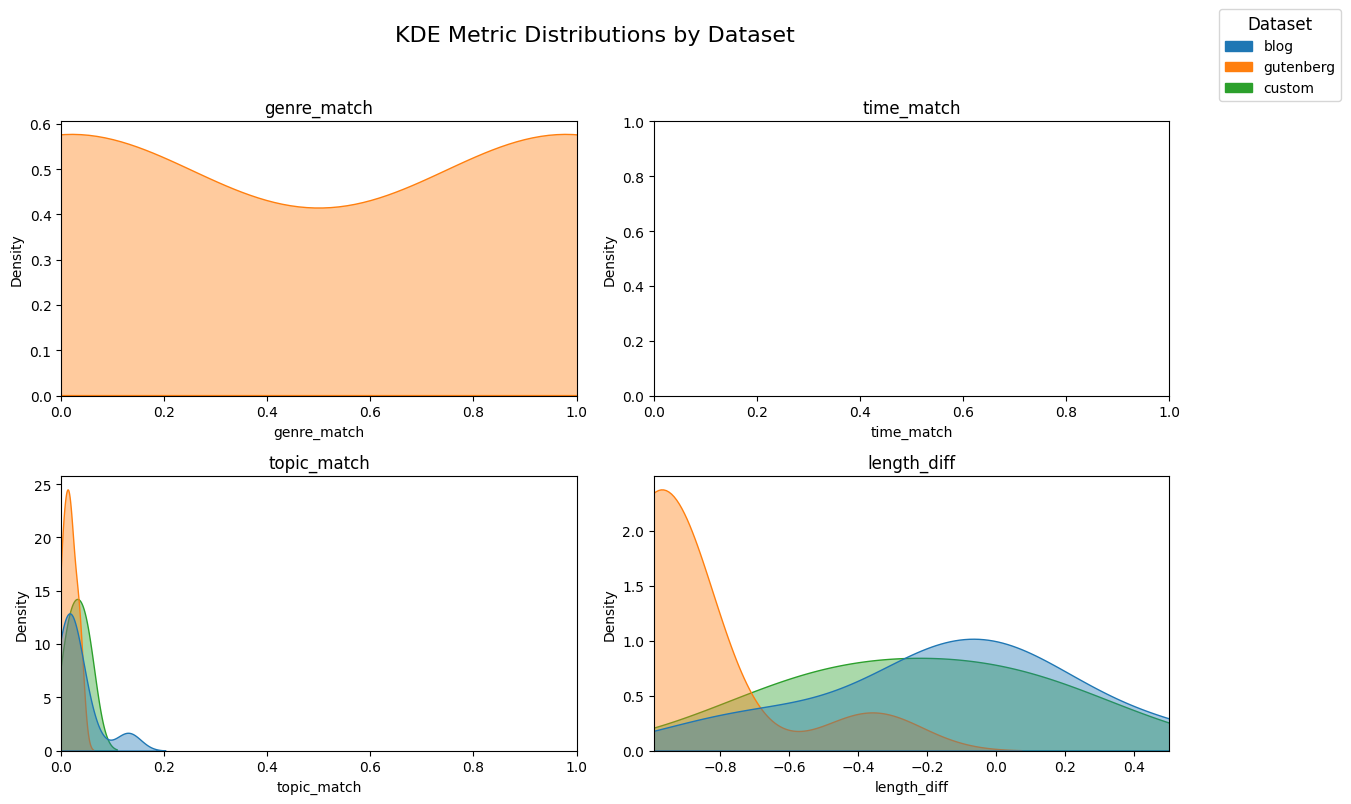

In [21]:
evaluator.evaluate_extractors(save_to_disk=True)

`length_diff` is perceptual difference in length between original and paraphrased text, where negative values indicate that the paraphrased text is shorter than the original text.

## Batch Processing

In [25]:
# Batch paraphrasing
# texts = ["The sky is blue.", "I love programming.", "Artificial intelligence is fascinating."]
# paraphrased_batch = bullet_point_paraphraser.paraphrase_batch(texts)
# for original, paraphrased in zip(texts, paraphrased_batch):
#     print(f"Original: {original} | Paraphrased: {paraphrased}")

In [26]:
import dirtyjson

d = dirtyjson.loads(
    """["foo", /* not fu*/ {bar: ['baz', null, 1.0, 2,]}] and then ignore this junk"""
)
d

['foo', AttributedDict([('bar', ['baz', None, 1.0, 2])])]